# Analytic DRT Functions

This notebook implements analytic expressions for the Distribution of Relaxation Times (DRT) and impedance for the Havriliak-Negami (HN) model.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

## Havriliak-Negami Model

The Havriliak-Negami (HN) model provides analytic expressions for both the impedance and the DRT.

In [19]:
def HN_Z(
    omega: float | np.ndarray,
    Z0: float,
    tau0: float,
    alpha: float,
    beta: float
) -> complex | np.ndarray:
    """
    Calculate the Havriliak-Negami impedance.

    Parameters
    ----------
    omega : float or np.ndarray
        Angular frequency (rad/s)
    Z0 : float
        Characteristic impedance magnitude (Ohm)
    tau0 : float
        Characteristic time constant (s)
    alpha : float
        Shape parameter (0 < alpha <= 1)
        Controls the symmetric broadening of the peak
    beta : float
        Shape parameter (0 < beta <= 1)
        Controls the asymmetric broadening of the peak

    Returns
    -------
    complex or np.ndarray
        Complex impedance Z(ω)

    Notes
    -----
    Implements equation:
    Z(ω) = Z0 / (1 + (jωτ0)^α)^β

    Special cases:
    - α=1, β=1: Debye (single time constant) AKA RC element
    - α<1, β=1: Cole-Cole (symmetric peak broadening) AKA RQ or ZARC element
    - α=1, β<1: Cole-Davidson (asymmetric peak broadening)
    - α=0.5, β=1: Gerischer element (semi-infinite diffusion)
    """
    # Convert to numpy array for consistent handling
    omega = np.asarray(omega)

    # Calculate (jωτ0)^α
    jwt0_alpha = (1j * omega * tau0) ** alpha

    # Calculate Z(ω) = Z0 / (1 + (jωτ0)^α)^β
    Z = Z0 / (1 + jwt0_alpha) ** beta

    return Z


In [171]:
def HN_DRT(
    tau: float | np.ndarray,
    Z0: float,
    tau0: float,
    alpha: float,
    beta: float
) -> float | np.ndarray:
    """
    Calculate the Havriliak-Negami Distribution of Relaxation Times (DRT).
    
    Parameters
    ----------
    tau : float or np.ndarray
        Time constant(s) (s)
    Z0 : float
        Characteristic impedance magnitude (Ohm)
    tau0 : float
        Characteristic time constant (s)
    alpha : float
        Shape parameter (0 < alpha <= 1)
        Controls the symmetric broadening of the peak
    beta : float
        Shape parameter (0 < beta <= 1)
        Controls the asymmetric broadening of the peak
        
    Returns
    -------
    float or np.ndarray
        DRT γ(τ) (Ohm)
        
    Notes
    -----
    Implements equations:
    
    γ(τ) = (Z0 * (τ/τ0)^(αβ) * sin(β*θ)) / 
           (π * ((τ/τ0)^(2α) + 2*(τ/τ0)^α * cos(πα) + 1)^(β/2))
    
    where:
    θ = arctan(|sin(πα) / ((τ/τ0)^α + cos(πα))|)
    """
    # Convert to numpy array for consistent handling
    tau = np.asarray(tau)
    
    # Calculate normalized time constant
    tau_ratio = tau / tau0
    tau_ratio_alpha = tau_ratio ** alpha
    
    # Calculate theta
    cos_pi_alpha = np.cos(np.pi * alpha)
    sin_pi_alpha = np.sin(np.pi * alpha)
    
    # theta = np.arctan(np.abs(sin_pi_alpha / (tau_ratio_alpha + cos_pi_alpha))) # doesn't do asymmetry well
    # theta = np.pi/2 - np.arctan((sin_pi_alpha / (tau_ratio_alpha + cos_pi_alpha))) # just wrong
    # theta = np.pi/2 - np.arctan(np.abs( (tau_ratio_alpha + cos_pi_alpha)/ sin_pi_alpha)) # doesn't do asymmetry well
    # theta = np.pi/2 - np.arctan(( (tau_ratio_alpha + cos_pi_alpha)/ sin_pi_alpha)) # works
    # theta = np.arctan(( (tau_ratio_alpha + cos_pi_alpha)/ sin_pi_alpha)) # way off
    # theta = np.arctan2((tau_ratio_alpha + cos_pi_alpha), (sin_pi_alpha)) # broken as hell
    theta = np.arctan2((sin_pi_alpha), (tau_ratio_alpha + cos_pi_alpha)) # seems to work

    # Calculate numerator: Z0 * (τ/τ0)^(αβ) * sin(β*θ)
    numerator = Z0 * (tau_ratio ** (alpha * beta)) * np.sin(beta * theta)
    
    # Calculate denominator: π * ((τ/τ0)^(2α) + 2*(τ/τ0)^α * cos(πα) + 1)^(β/2)
    denominator_base = (
        tau_ratio ** (2 * alpha) + 
        2 * tau_ratio_alpha * cos_pi_alpha + 
        1

    # 1 / np.pi * (tau_s / tau_c)**(alpha * beta) * np.sin(beta * theta) / (1 + 2 * np.cos(np.pi*alpha) * (tau_s / tau_c)**alpha + (tau_s / tau_c)**(2*alpha))**(beta / 2)
)
    denominator = np.pi * (denominator_base ** (beta / 2))
    
    # Calculate γ(τ)
    gamma = numerator / denominator
    
    return gamma

In [39]:
from scipy.integrate import quad, trapezoid
import numpy as np

def reconstruct_Z_DRT(f, gamma, tau=None, R0=0.0, L0=0.0, quad_opts=None):
    """
    Reconstruct impedance Z_DRT(f) from DRT using either analytic or vectorized gamma.

    Parameters
    ----------
    f : float or np.ndarray
        Frequency (Hz), can be scalar or array.
    gamma : callable or np.ndarray
        If callable: gamma(tau) returns DRT value for tau.
        If array: vector of gamma values corresponding to tau.
    tau : np.ndarray, optional
        Array of tau values (required if gamma is array).
    R0 : float, optional
        Ohmic resistance (default 0.0)
    L0 : float, optional
        Inductance (default 0.0)
    quad_opts : dict, optional
        Dictionary of options for scipy.integrate.quad. Supported keys:
        - 'a', 'b': integration limits (default -50, 50)
        - 'epsabs', 'epsrel': error tolerances
        - 'limit': max subdivisions (default None, i.e. no limit)
        If a key is provided, its value will override the default. If not provided, defaults are used.

    Returns
    -------
    Z_DRT : complex or np.ndarray
        Reconstructed impedance at each frequency.
    """
    f = np.atleast_1d(f)
    Z_DRT = np.zeros(f.shape, dtype=complex)
    # Default quad options
    default_opts = {'a': -50, 'b': 50, 'epsabs': 1e-9, 'epsrel': 1e-9, 'limit': 100}
    quad_opts = quad_opts or {}
    opts = {**default_opts, **quad_opts}
    a = opts['a']
    b = opts['b']
    quad_args = {k: v for k, v in opts.items() if k not in ['a', 'b']}
    if callable(gamma):
        for i, fi in enumerate(f):
            def real_integrand(ln_tau):
                tau_val = np.exp(ln_tau)
                denom = 1 + (2 * np.pi * fi * tau_val) ** 2
                return gamma(tau_val) / denom
            def imag_integrand(ln_tau):
                tau_val = np.exp(ln_tau)
                denom = 1 + (2 * np.pi * fi * tau_val) ** 2
                return -gamma(tau_val) * (2 * np.pi * fi * tau_val) / denom
            real_integral, _ = quad(real_integrand, a, b, **quad_args)
            imag_integral, _ = quad(imag_integrand, a, b, **quad_args)
            integral = real_integral + 1j * imag_integral
            Z_DRT[i] = R0 + 1j * 2 * np.pi * fi * L0 + integral
    else:
        if tau is None:
            raise ValueError("tau array must be provided when gamma is vectorized.")
        # Ensure tau is in ascending order
        if not np.all(np.diff(tau) > 0):
            sort_idx = np.argsort(tau)
            tau = tau[sort_idx]
            gamma = gamma[sort_idx]
        ln_tau = np.log(tau)
        for i, fi in enumerate(f):
            kernel = gamma / (1 + 1j * 2 * np.pi * fi * tau)
            Z_DRT[i] = R0 + 1j * 2 * np.pi * fi * L0 + trapezoid(kernel, ln_tau)
    return Z_DRT if Z_DRT.size > 1 else Z_DRT[0]


## Example: Calculate and Plot HN Model

0.5
0.5


C:\Users\es758\AppData\Local\Temp\ipykernel_25568\1158723162.py:74: RuntimeWarning: divide by zero encountered in scalar divide
  gamma = numerator / denominator


Parameters: Z0=4.0 Ω, τ0=3.0 s, α=1, β=0.5
Number of frequency points: 50
Number of time constant points: 200


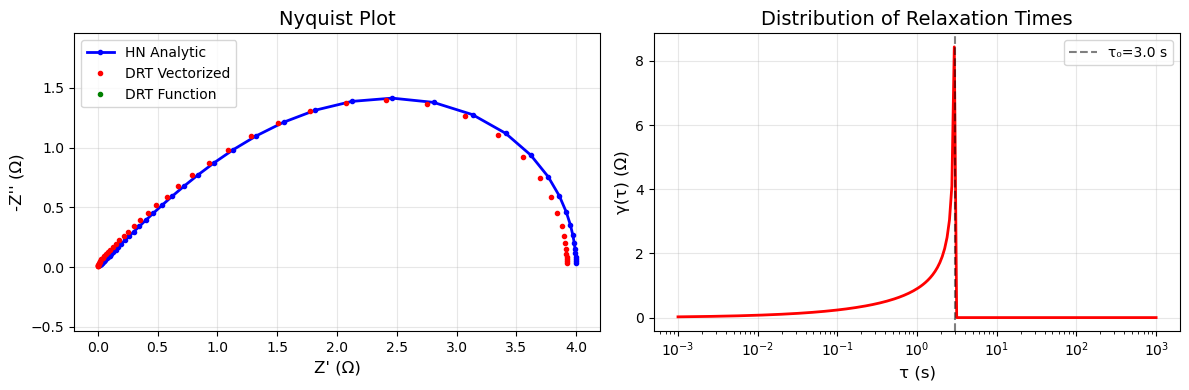

In [172]:
# Define HN parameters
Z0 = 4.0      # Characteristic impedance (Ohm)
tau0 = 3.0e0      # Characteristic time constant (s)
alpha = 1    # Symmetric broadening parameter
beta = 0.5     # Asymmetric broadening parameter

# Create frequency array
f = np.logspace(-3, 3, 50)  # Frequency in Hz decade spacing
omega = 2 * np.pi * f        # Angular frequency in rad/s

# Create time constant array
tau = np.logspace(-3, 3, 200)  # Time constants in s
#tau = 1/omega
# tau = tau[::-1]

# Calculate impedance (analytic HN)
Z = HN_Z(omega, Z0, tau0, alpha, beta)
print(beta)
# Calculate DRT
gamma = HN_DRT(tau, Z0, tau0, alpha, beta)
print(beta)

# Reconstruct impedance from DRT (vectorized gamma)
Z_DRT_vec = reconstruct_Z_DRT(f, gamma, tau=tau, R0=0.0, L0=0.0)

# Reconstruct impedance from DRT (function/callable gamma)
def gamma_func(tau):
    return HN_DRT(tau, Z0, tau0, alpha, beta)
Z_DRT_func = reconstruct_Z_DRT(f, gamma_func, R0=0.0, L0=0.0, quad_opts={'a': -50, 'b': 50, 'epsabs': 1e-9, 'epsrel': 1e-9, 'limit': 100})

print(f"Parameters: Z0={Z0} Ω, τ0={tau0} s, α={alpha}, β={beta}")
print(f"Number of frequency points: {len(f)}")
print(f"Number of time constant points: {len(tau)}")

# Plot impedance (Nyquist plot) and DRT
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Nyquist plot: analytic HN and reconstructed Z (both methods)
axes[0].plot(Z.real, -Z.imag, 'b.-', linewidth=2, label='HN Analytic')
axes[0].plot(Z_DRT_vec.real, -Z_DRT_vec.imag, 'r.', linewidth=2, label='DRT Vectorized')
axes[0].plot(Z_DRT_func.real, -Z_DRT_func.imag, 'g.', linewidth=2, label='DRT Function')
axes[0].set_xlabel("Z' (Ω)", fontsize=12)
axes[0].set_ylabel("-Z'' (Ω)", fontsize=12)
axes[0].set_title('Nyquist Plot', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')
axes[0].legend()

# DRT plot
axes[1].plot(tau, gamma, 'r-', linewidth=2)
axes[1].axvline(tau0, color='k', linestyle='--', alpha=0.5, label=f'τ₀={tau0} s')
axes[1].set_xlabel('τ (s)', fontsize=12)
axes[1].set_ylabel('γ(τ) (Ω)', fontsize=12)
axes[1].set_title('Distribution of Relaxation Times', fontsize=14)
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()